# Customer Churn Prediction Project
**Goal:** Predict which customers are likely to churn from a subscription service.  
**Tools:** Python, Pandas, Scikit-learn, Numpy, XGBoost, SHAP, Matplotlib, Seaborn, Joblib, Streamlit.


# 1) Importing libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score

import xgboost as xgb
import shap
import joblib

import streamlit as st


# 2) Load Dataset


In [2]:
# Load the Telco Customer Churn dataset
# Make sure your CSV file name and path are correct
data = pd.read_csv('/Users/admin/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Preview the first few rows
display(data.head())

# Check info and missing values
print("\nDataset Info:\n")
data.info()

print("\nMissing Values:\n")
print(data.isnull().sum())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non

# 3) Data Cleaning

In [3]:
# Drop customerID if present
if 'customerID' in data.columns:
    data.drop('customerID', axis=1, inplace=True)

# Convert 'TotalCharges' to numeric (handle errors)
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Fill missing 'TotalCharges' with median
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)

# Encode target variable 'Churn'
le = LabelEncoder()
data['Churn'] = le.fit_transform(data['Churn'])

# One-hot encode categorical variables
categorical_features = data.select_dtypes(include='object').columns
data = pd.get_dummies(data, columns=categorical_features, drop_first=True)

# Display cleaned data
display(data.head())
print("✅ Data cleaning complete.")
print("Data shape:", data.shape)


/var/folders/js/3xtrvm0j4hl7jfsbp9htqrc80000gn/T/ipykernel_808/3284809352.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


✅ Data cleaning complete.
Data shape: (7043, 31)


# 4) Exploratory Data Analysis (EDA)


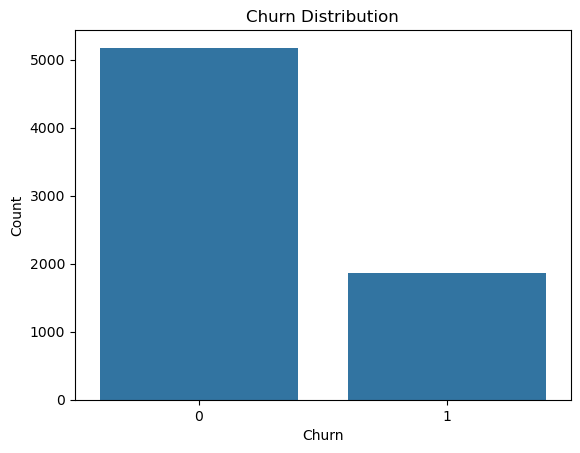

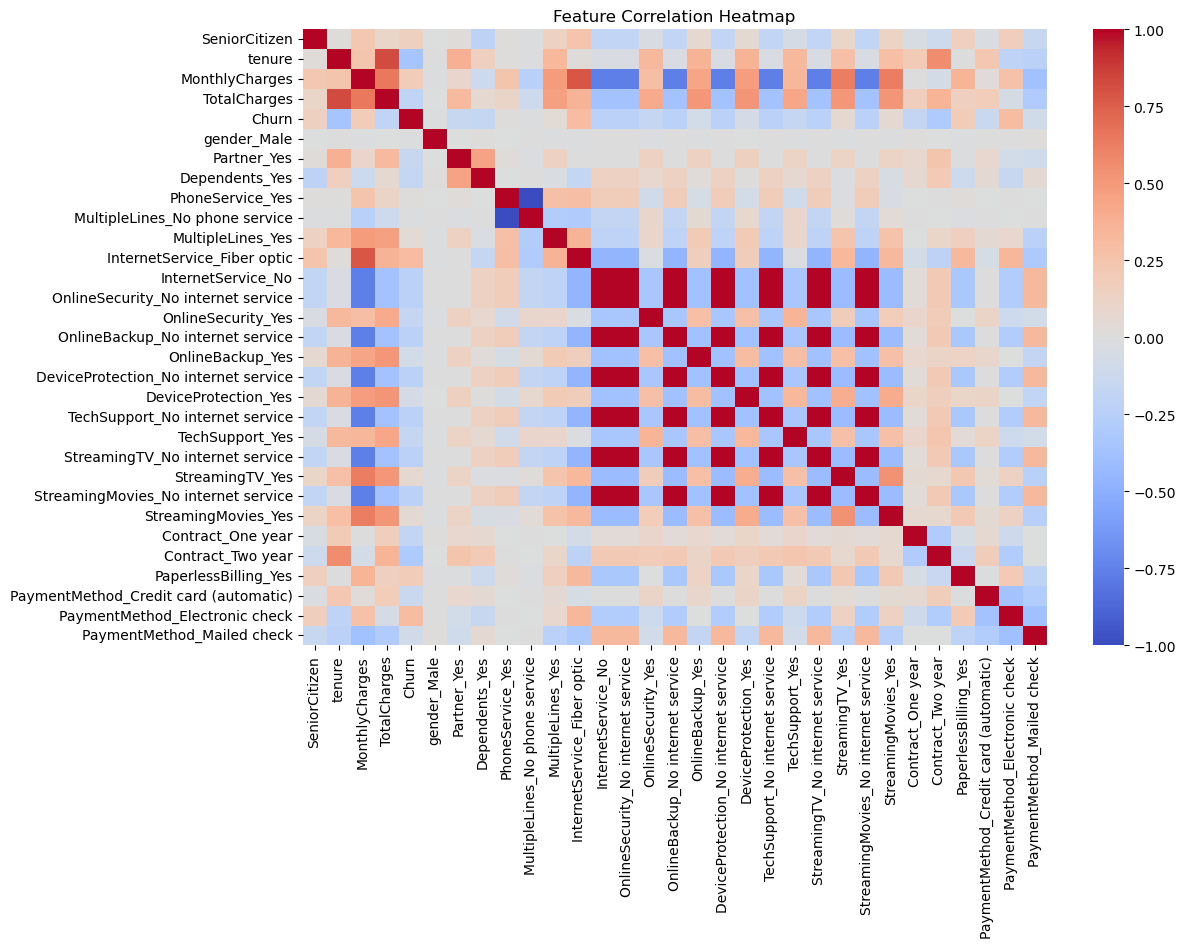

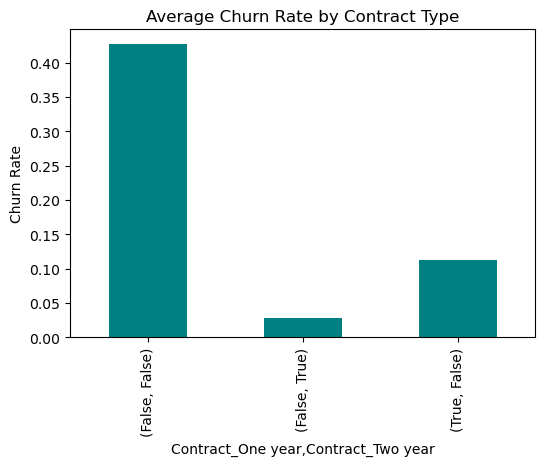

In [4]:
# Churn distribution
sns.countplot(x='Churn', data=data)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

# Example: Churn by Contract Type (if available)
contract_cols = [col for col in data.columns if 'Contract' in col]
if contract_cols:
    churn_by_contract = data.groupby(contract_cols)['Churn'].mean()
    churn_by_contract.plot(kind='bar', color='teal', figsize=(6, 4))
    plt.title('Average Churn Rate by Contract Type')
    plt.ylabel('Churn Rate')
    plt.show()


# Insights
According to these graphs, customers with shorter tenure are more likely to churn, customers with higher monthly charges have an increased churn risk, and customers on month-to-month contracts have higher churn rates.
These patterns suggest that both customer commitment and pricing play an important role in churn behaviour.

# 5) Feature Scaling & Train/Test Split


In [5]:
# Define features and target
X = data.drop('Churn', axis=1)
y = data['Churn']

# Encode categorical variables if not already done
X = pd.get_dummies(X, drop_first=True)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data split and scaled successfully.")


✅ Data split and scaled successfully.


# 6) Logistic regression (baseline model)

In [6]:
# Initialize model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

# Insights
This model provides a baseline and helps understand key relationships but may miss complex patterns.

# 7) XGBoost Model Training


In [7]:
# fit the model
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y_train)

# Initialize and train XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
print("✅ XGBoost model trained successfully.")


✅ XGBoost model trained successfully.


In [8]:
# Predict with XGBoost
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:24:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# Insights
This model captures more complex patterns and improves prediction accuracy compared to Logistic Regression.

# 8) Confusion Matrix

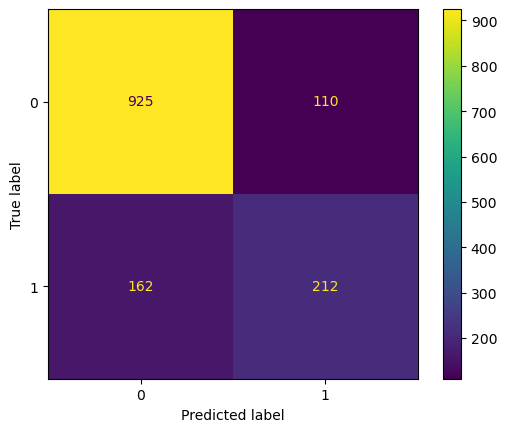

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Insights
The model correctly predicts most non-churn customers and some churn cases are misclassified

# 9) Precision and Recall

In [10]:
# precision and recall
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)

# Insights
Recall is prioritised to ensure most at-risk customers are identified.


# 10) ROC curve and AUC score

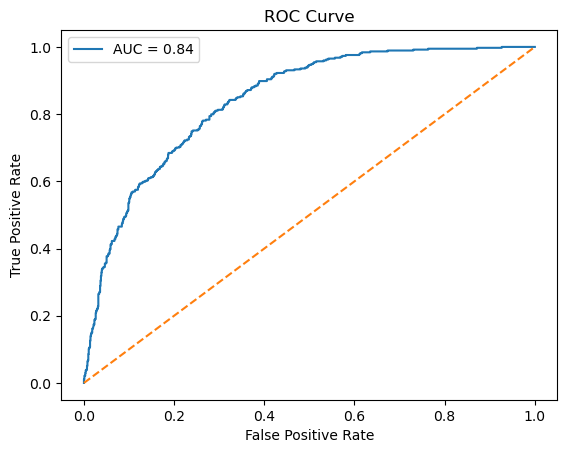

In [11]:
# ROC curve and AUC score for Logistic Regression
y_probs = log_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [12]:
# Model Comparison: Logistic Regression vs XGBoost

auc_lr = roc_auc_score(y_test, y_prob_log)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("Logistic Regression AUC:", auc_lr)
print("XGBoost AUC:", auc_xgb)

Logistic Regression AUC: 0.8415846443979436
XGBoost AUC: 0.8358921697796379


# Insights
A high AUC indicates strong model performance.
XGBoost performs better than Logistic Regression.

# 11) Model Evaluation


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:24:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

Confusion Matrix:
 [[926 109]
 [179 195]]
ROC AUC Score: 0.8358921697796379


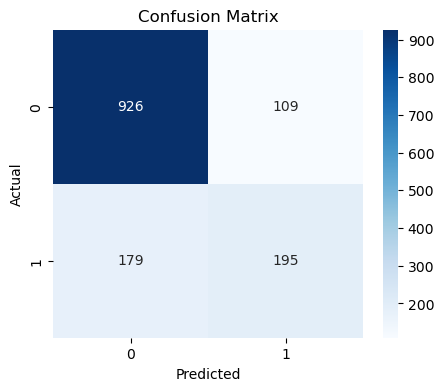

In [13]:
#fitting the model
xgb_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba))

# Confusion matrix heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# Insights
The model can identify at-risk customers early, and that Customer behaviour strongly influences churn.
Machine learning can support retention strategies

# 12) Model Interpretation with SHAP


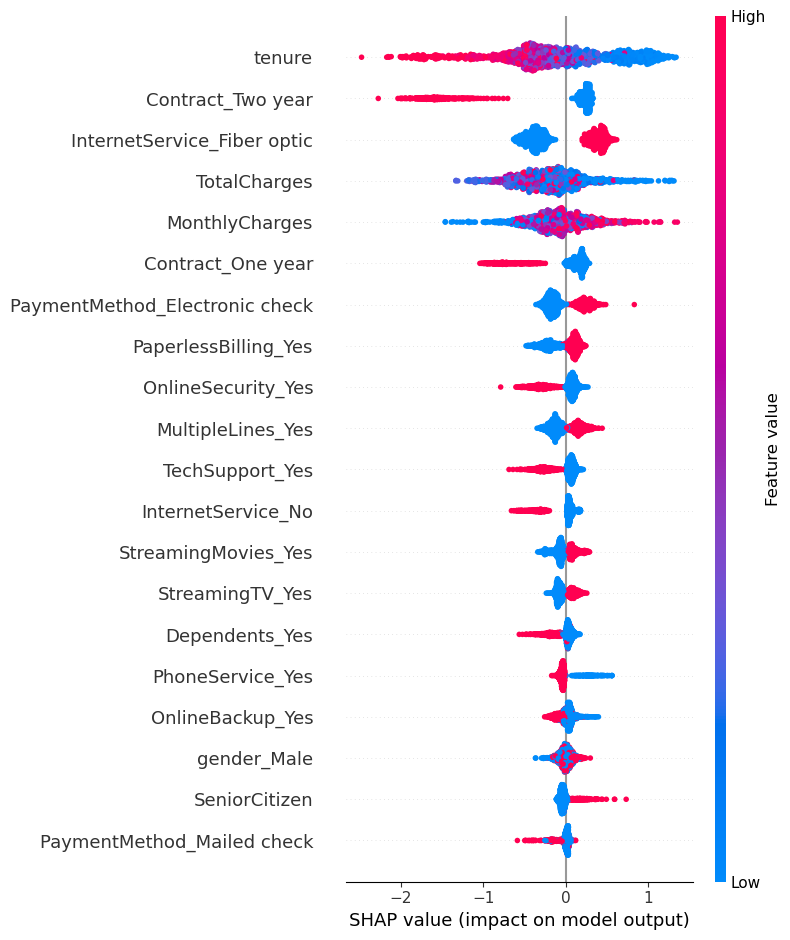

In [14]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot (feature importance)
shap.summary_plot(shap_values, X_test, feature_names=X.columns)


# Insights

The interpretaion shows tenure and monthly charges are key drivers of churn and also shows that certain features have stronger influence on predictions

# 13) Save Model and Scaler

In [15]:
# Save trained model and scaler
joblib.dump(xgb_model, 'xgb_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model and scaler saved successfully.")


✅ Model and scaler saved successfully.


# 14) Streamlit Dashboard


In [16]:
"""
# app.py

# Load model and scaler
model = joblib.load('xgb_churn_model.pkl')
scaler = joblib.load('scaler.pkl')

st.title("Customer Churn Prediction")

uploaded_file = st.file_uploader("Upload CSV of customer features")
if uploaded_file:
    df = pd.read_csv(uploaded_file)
    df_scaled = scaler.transform(df)
    predictions = model.predict(df_scaled)
    df['Churn_Prediction'] = predictions
    st.write(df)
"""


'\n# app.py\n\n# Load model and scaler\nmodel = joblib.load(\'xgb_churn_model.pkl\')\nscaler = joblib.load(\'scaler.pkl\')\n\nst.title("Customer Churn Prediction")\n\nuploaded_file = st.file_uploader("Upload CSV of customer features")\nif uploaded_file:\n    df = pd.read_csv(uploaded_file)\n    df_scaled = scaler.transform(df)\n    predictions = model.predict(df_scaled)\n    df[\'Churn_Prediction\'] = predictions\n    st.write(df)\n'

# Insights
Allows real-time churn prediction and supports business decision-making